<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 11 - Ejemplo 2 - Regresión de Ridge, Lasso y Red Elástica
        </td>
    </tr>
    <tr>
 

</table>

In [1]:
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

## Ejercicio 2

Este conjunto de datos explora la relación entre el uso de redes sociales y los niveles de productividad en los individuos. Incluye características de comportamiento, estilo de vida y actividad digital para simular patrones de uso del mundo real.


<table border="1" cellspacing="0" cellpadding="6">
  <thead>
    <tr>
      <th>Variable</th>
      <th>Descripción</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>age</td>
      <td>Edad del individuo</td>
    </tr>
    <tr>
      <td>daily_screen_time</td>
      <td>Tiempo total de pantalla por día (horas)</td>
    </tr>
    <tr>
      <td>social_media_hours</td>
      <td>Tiempo dedicado a las redes sociales (horas)</td>
    </tr>
    <tr>
      <td>study_hours</td>
      <td>Tiempo productivo de trabajo o estudio</td>
    </tr>
    <tr>
      <td>sleep_hours</td>
      <td>Duración diaria del sueño</td>
    </tr>
    <tr>
      <td>notifications_per_day</td>
      <td>Número de notificaciones recibidas por día</td>
    </tr>
    <tr>
      <td>focus_score</td>
      <td>Nivel de concentración calculado (0–100)</td>
    </tr>
    <tr>
      <td>addiction_level</td>
      <td>Nivel de adicción: Bajo / Medio / Alto</td>
    </tr>
    <tr>
      <td>productivity_score</td>
      <td>Variable objetivo (0–100)</td>
    </tr>
  </tbody>
</table>

## Parte 1

<p>Realizar lo siguiente:</p>
<ul style="list-style-type: disc;">
    <li>Describir el conjunto de datos proporcionado (Notar que hay valores nulos en las variables incluso en la variable objetivo ).</li>
    <li>Eliminar las observaciones que tienen valores faltantes y realizar la estandarización de los valores.</li>
    <li>Dividir el conjunto de datos en 25% de observaciones para la validaci&oacute;n y el 75% restante pata el entrenamiento 
    <li>Realizar un modelo de regresión Ridge del nivel de productividad con $\alpha=10$ y $\alpha=100$
    <li> Comparar los dos modelos anterior con la regresión lineal múltiple.
    <li> Realizar la validación cruzada para determinar el valor de $\alpha$ que proporciona un menor error cuadrático

In [2]:
data = pd.read_csv("social_media_productivity_6000.csv")

In [3]:
data

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09
...,...,...,...,...,...,...,...,...,...
5995,20.0,2.05,0.71,7.92,4.13,48.0,100.00,Low,84.55
5996,28.0,6.28,4.90,4.07,5.64,198.0,99.52,Medium,37.63
5997,19.0,3.97,3.40,0.93,6.10,183.0,98.65,Medium,6.67
5998,30.0,11.11,9.16,3.76,6.43,179.0,79.82,High,0.00


In [4]:
#Mostrar la información de las variables
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB


In [5]:
#Contar los valores nulos
data.isnull().sum()

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

In [7]:
#Se eliminan los datos faltantes
data = data.dropna(axis=0)
data.isnull().sum()

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

In [8]:
#Separar variables independientes y la dependiente
predictoras = data.drop(["productivity_score", "addiction_level"], axis=1)
respuesta = data["productivity_score"]

In [9]:
#Estandarizar las variables independientes

from sklearn.preprocessing import StandardScaler
escalar = StandardScaler()
escalar.fit(predictoras)

predictoras_esc = pd.DataFrame(escalar.transform(predictoras), columns = predictoras.columns)
predictoras_esc

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score
0,-0.856149,-0.341869,-0.619730,-0.634626,0.334203,1.517967,0.492025
1,0.934427,-1.086400,-0.842160,-1.641953,0.668768,1.308671,-0.362472
2,0.245744,-1.173786,-1.161905,0.489428,-0.118853,-0.279518,0.492025
3,-0.305203,1.168166,0.103170,0.087363,-1.408320,1.074751,-0.219831
4,-0.718413,-1.575763,-1.180440,-0.176358,-0.118853,-1.621476,0.492025
...,...,...,...,...,...,...,...
4994,-0.029730,0.699775,0.719489,0.039806,-0.223404,-0.144091,0.492025
4995,-0.993886,-1.705094,-1.592864,1.661039,-1.659243,-1.375245,0.492025
4996,0.108007,-0.226519,0.348771,-0.003426,-0.606759,0.471486,0.427433
4997,-1.131623,-1.033968,-0.346325,-1.360939,-0.286135,0.286813,0.310360


In [21]:
#Realizar la división de los datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(predictoras_esc,respuesta,
                                                    test_size = 0.25 , random_state = 2026)

In [22]:
#Importar clase
from sklearn.linear_model import Ridge

#Ajustar el modelo ridge con alfa=10
ridge_reg = Ridge(alpha=10)
ridge_reg.fit(X_train,y_train)

#Obtener coeficientes del modelo
#Intercepto
print("El intercepto que se tiene es %s" %ridge_reg.intercept_)
#Coeficientes de regresion
coefs_ridge_a = pd.DataFrame({"Variables": predictoras.columns, "Coeficientes": ridge_reg.coef_})
coefs_ridge_a

El intercepto que se tiene es 37.66057755938239


,Variables,Coeficientes
0,age,0.078421
1,daily_screen_time,-0.191346
2,social_media_hours,-17.140910
3,study_hours,22.467376
4,sleep_hours,7.192211
5,notifications_per_day,-2.995890
6,focus_score,-5.331667


In [23]:
#Ajustar el modelo ridge con alfa=100
ridge_reg_b = Ridge(alpha=100)
ridge_reg_b.fit(X_train,y_train)

#Obtener coeficientes del modelo
#Intercepto
print("El intercepto que se tiene es %s" %ridge_reg_b.intercept_)
#Coeficientes de regresion
coefs_ridge_b = pd.DataFrame({"Variables": predictoras.columns, "Coeficientes": ridge_reg_b.coef_})
coefs_ridge_b

El intercepto que se tiene es 37.649585597392274


,Variables,Coeficientes
0,age,0.059756
1,daily_screen_time,-1.049901
2,social_media_hours,-15.197794
3,study_hours,21.388657
4,sleep_hours,6.742135
5,notifications_per_day,-2.658383
6,focus_score,-3.864888


In [24]:
#Importar clase para la regresión lineal
from sklearn.linear_model import LinearRegression

#Ajustar el modelo
lm = LinearRegression()
lm.fit(X_train, y_train)

#Obtener error para cada uno
y_pred_lm = lm.predict(X_test)
y_pred_ridge_a = ridge_reg.predict(X_test)
y_pred_ridge_b = ridge_reg_b.predict(X_test)


mse_lm = mean_squared_error(y_test, y_pred_lm)
mse_ridge_a = mean_squared_error(y_test, y_pred_ridge_a)
mse_ridge_b = mean_squared_error(y_test, y_pred_ridge_b)
errores_ridge = [mse_lm, mse_ridge_a, mse_ridge_b,]

comparación_ridge = pd.DataFrame({"Modelo": ["Lineal", r"Ridge $\alpha=10$", r"Ridge $\alpha=100$"], 
                                  "MSE": errores_ridge})

comparación_ridge

,Modelo,MSE
0,Lineal,97.463695
1,Ridge $\alpha=10$,97.446310
2,Ridge $\alpha=100$,98.965686


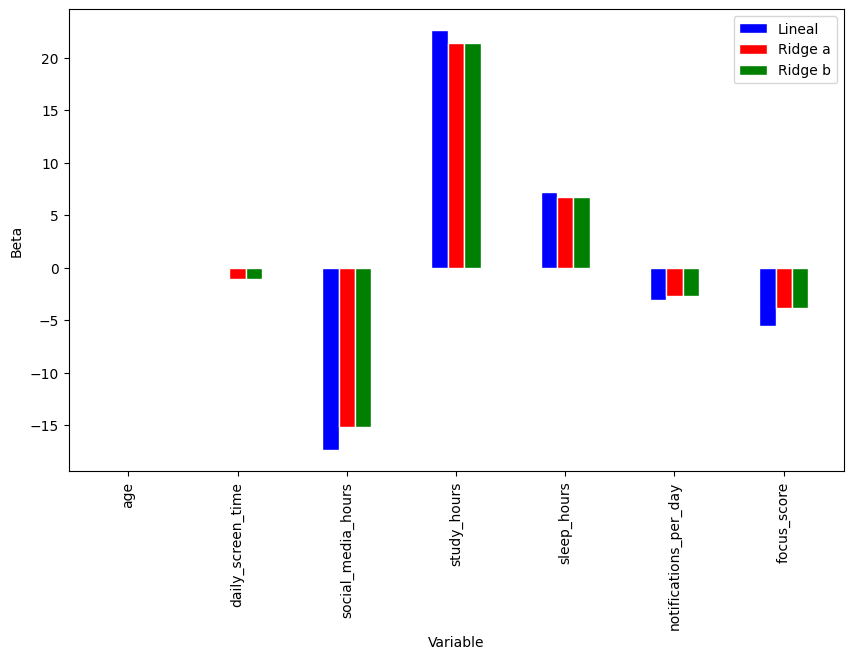

In [19]:
fig = plt.figure(figsize=(10, 6))

#Ancho de barra
barWidth = 0.15

#Definir posicion barras series
r1 = np.arange(len(lm.coef_))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

#Pintar las barras
plt.bar(r1, lm.coef_, color = "blue", width = barWidth, edgecolor = "white", label = "Lineal")
plt.bar(r2, ridge_reg.coef_, color = "red", width = barWidth, edgecolor = "white", label = "Ridge a")
plt.bar(r3, ridge_reg_b.coef_, color = "green", width = barWidth, edgecolor = "white", label = "Ridge b")

plt.xticks([r + barWidth for r in range(len(lm.coef_))], 
           [predictoras.columns[i] for i in range(len(predictoras.columns))],rotation=90); 
plt.legend()
plt.xlabel("Variable");
plt.ylabel("Beta");
plt.show(fig)

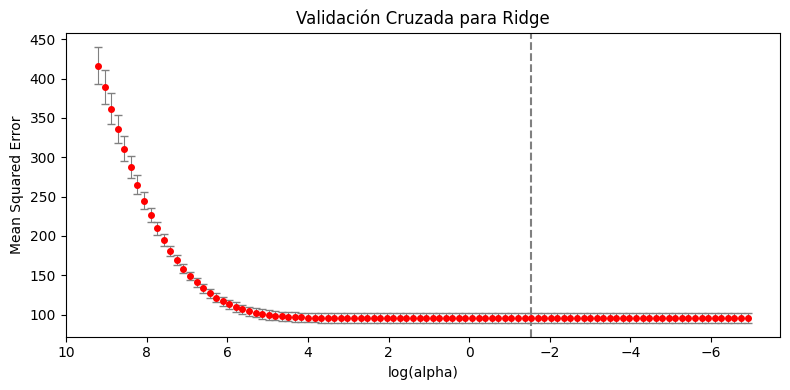

El valor de alpha que minimiza el mse es 0.21544346900318823


In [26]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score

alphas = np.logspace(-3, 4, 100)
ridge = RidgeCV(alphas=alphas, cv=10)
ridge.fit(X_train, y_train)
kf = KFold(n_splits=10, shuffle=True, random_state=2026)

mse_mean = list()
mse_std = list()

for alpha in alphas:
    modelo_tmp = RidgeCV(alphas=[alpha], cv=None)  
    scores = cross_val_score(modelo_tmp, X_train, y_train, scoring='neg_mean_squared_error',cv=kf)
    
    mse = -scores
    mse_mean.append(mse.mean())
    mse_std.append(mse.std())

mse_mean = np.array(mse_mean)
mse_std = np.array(mse_std)

alpha_min_ridge = ridge.alpha_


idx_min = np.argmin(mse_mean)
mse_min = mse_mean[idx_min]
se_min = mse_std[idx_min]

idx_1se = np.where(mse_mean <= mse_min + se_min)[0][0]
alpha_1se = alphas[idx_1se]

#Realizar el gráfico
x = np.log(alphas)

plt.figure(figsize=(8, 4))
plt.errorbar(x, mse_mean, yerr=mse_std, fmt='o', color='red', ecolor='gray', elinewidth=0.8, capsize=3, markersize=4)
plt.axvline(np.log(alpha_min_ridge), linestyle='--', color="gray")

plt.xlabel("log(alpha)")
plt.ylabel('Mean Squared Error')
plt.title('Validación Cruzada para Ridge')
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

print("El valor de alpha que minimiza el mse es %s" %alpha_min_ridge)

## Parte 2

<p>Realizar lo siguiente:</p>
<ul style="list-style-type: disc;">
    <li>Realizar un modelo de regresión Lasso del nivel de productividad con $\alpha=0.05$ y $\alpha=1$
    <li> Comparar los dos modelos anterior con la regresión lineal múltiple.
    <li> Realizar la validación cruzada para determinar el valor de $\alpha$ que proporciona un menor error cuadrático

In [28]:
#Importar clase
from sklearn.linear_model import Lasso

#Ajustar el modelo de Lasso con alfa=0.05
lasso_reg = Lasso(alpha=0.05)
lasso_reg.fit(X_train, y_train)

#Intercepto
print("El intercepto que se tiene es %s" %lasso_reg.intercept_)
#Coeficientes de regresion
coefs_lasso_a = pd.DataFrame({"Variables": predictoras.columns, "Coeficientes": lasso_reg.coef_})
coefs_lasso_a

El intercepto que se tiene es 37.66052785128575


,Variables,Coeficientes
0,age,0.026854
1,daily_screen_time,-0.086244
2,social_media_hours,-17.150726
3,study_hours,22.434634
4,sleep_hours,7.137281
5,notifications_per_day,-2.934113
6,focus_score,-5.221037


In [29]:
#Importar clase
from sklearn.linear_model import Lasso

#Ajustar el modelo de Lasso con alfa=1
lasso_reg_b = Lasso(alpha=0.1)
lasso_reg_b.fit(X_train, y_train)

#Intercepto
print("El intercepto que se tiene es %s" %lasso_reg_b.intercept_)
#Coeficientes de regresion
coefs_lasso_b = pd.DataFrame({"Variables": predictoras.columns, "Coeficientes": lasso_reg_b.coef_})
coefs_lasso_b

El intercepto que se tiene es 37.65881790229956


,Variables,Coeficientes
0,age,0.000000
1,daily_screen_time,-0.094571
2,social_media_hours,-16.910962
3,study_hours,22.269514
4,sleep_hours,7.026545
5,notifications_per_day,-2.828780
6,focus_score,-4.923035


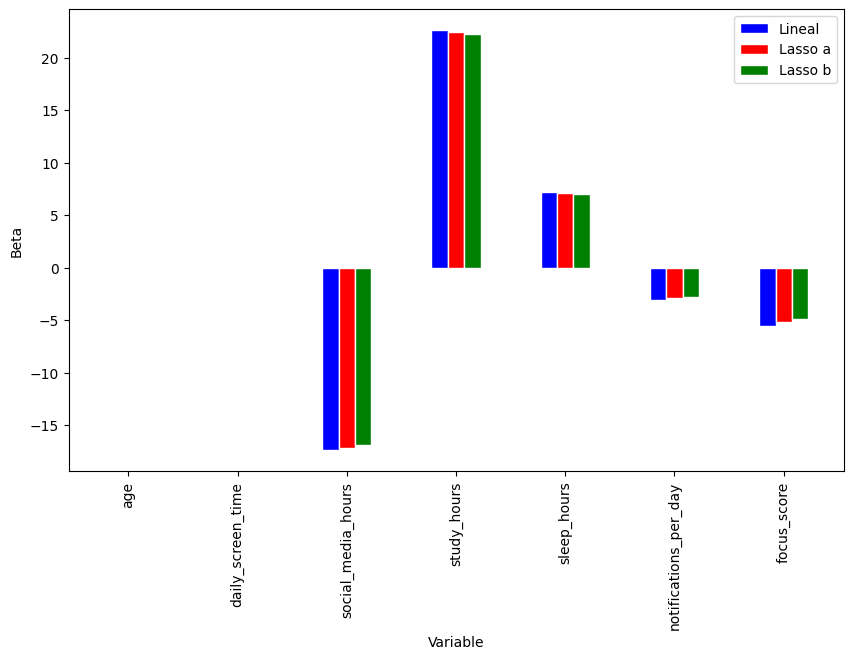

In [30]:
fig = plt.figure(figsize=(10, 6))

#Ancho de barra
barWidth = 0.15

#Definir posicion barras series
r1 = np.arange(len(lm.coef_))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

#Pintar las barras
plt.bar(r1, lm.coef_, color = "blue", width = barWidth, edgecolor = "white", label = "Lineal")
plt.bar(r2, lasso_reg.coef_, color = "red", width = barWidth, edgecolor = "white", label = "Lasso a")
plt.bar(r3, lasso_reg_b.coef_, color = "green", width = barWidth, edgecolor = "white", label = "Lasso b")

plt.xticks([r + barWidth for r in range(len(lm.coef_))], 
           [predictoras.columns[i] for i in range(len(predictoras.columns))],rotation=90); 
plt.legend()
plt.xlabel("Variable");
plt.ylabel("Beta");
plt.show(fig)

In [31]:
#Obtener error para cada uno
y_pred_lasso = lasso_reg.predict(X_test)
y_pred_lasso_b = lasso_reg_b.predict(X_test)


mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_lasso_b = mean_squared_error(y_test, y_pred_lasso_b)
errores_lasso = [mse_lm, mse_lasso, mse_lasso_b]

comparación_lasso = pd.DataFrame({"Modelo": ["Lineal", r"Lasso $\alpha=0.05$", r"Lasso $\alpha=1$"], 
                                  "MSE": errores_lasso})

comparación_lasso

,Modelo,MSE
0,Lineal,97.463695
1,Lasso $\alpha=0.05$,97.403308
2,Lasso $\alpha=1$,97.471407


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.


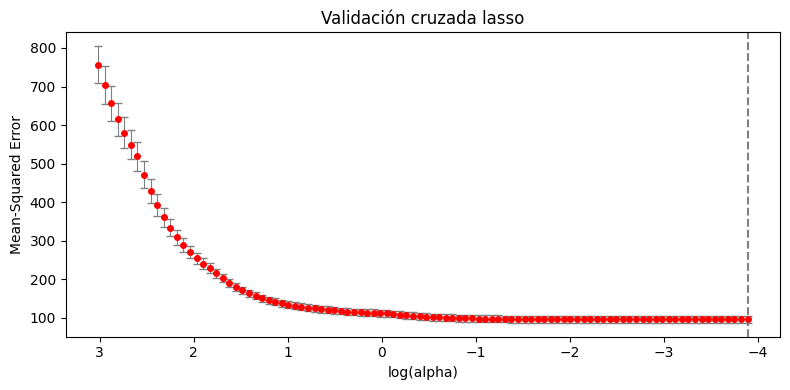

El valor de alpha que minimiza el mse es 0.020442874106816167


In [33]:
from sklearn.linear_model import LassoCV, lasso_path

# Ajustar LassoCV
lasso_cv = LassoCV(cv=10, random_state=2026, n_alphas=100)
lasso_cv.fit(X_train, y_train)


alphas = lasso_cv.alphas_
mse_path = lasso_cv.mse_path_
mse_mean = mse_path.mean(axis=1)
mse_std = mse_path.std(axis=1)
alpha_min = lasso_cv.alpha_

idx_min = np.argmin(mse_mean)
mse_min = mse_mean[idx_min]
se_min = mse_std[idx_min]
idx_1se = np.where(mse_mean <= mse_min + se_min)[0][0]
alpha_1se = alphas[idx_1se]

#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(predictoras_est)
alphas_path, coefs_path, _ = lasso_path(X_train, y_train, alphas=alphas)
n_nonzero = np.sum(coefs_path != 0, axis=0)

x = np.log(alphas)

fig, ax = plt.subplots(figsize=(8, 4))

plt.errorbar(x, mse_mean, yerr=mse_std, fmt='o', color='red', ecolor='gray', elinewidth=0.8, capsize=3, markersize=4)


ax.set_xlabel('log(alpha)')
ax.set_ylabel('Mean-Squared Error')
ax.set_title('Validación cruzada lasso')
ax.invert_xaxis()

plt.axvline(np.log(alpha_min), linestyle='--', color="gray")
plt.tight_layout()
plt.show()

print("El valor de alpha que minimiza el mse es %s" %alpha_min )

## Parte 3

Realizar un modelo de Red elástica del nivel de productividad  con las variables restantes.

a) Fijando $r=0.1$

b) Fijando $r=0.90$ (En ambos casos ajustar por validación cruzada con $k=10$ particiones)

c) Comparar los modelos con el modelo regresión lineal múltiple. ¿Qué se observa?

d) Realizar la validación cruzada para determinar el valor de $\alpha$ y $r$ que proporciona un menor error cuadrático.

In [38]:
#Importar clase
from sklearn.linear_model import ElasticNetCV

#Ajustar el modelo con r=0.1, cv, l1_ratio, random_state
e_net = ElasticNetCV(cv=10, l1_ratio= 0.1, random_state=2026)
e_net.fit(X_train, y_train)
#Obtener coeficientes del modelo

#Intercepto
print("El intercepto que se tiene es %s" %e_net.intercept_)
#Coeficientes de regresion
coefs_e_net = pd.DataFrame({"Variables": predictoras.columns, "Coeficientes": e_net.coef_})
coefs_e_net

El intercepto que se tiene es 37.60950866132776


,Variables,Coeficientes
0,age,-0.000000
1,daily_screen_time,-2.989874
2,social_media_hours,-9.444838
3,study_hours,17.022567
4,sleep_hours,5.060414
5,notifications_per_day,-1.576567
6,focus_score,0.745758


In [40]:

#Ajustar el modelo con r=0.9
e_net_b = ElasticNetCV(cv=10, l1_ratio= 0.9, random_state=2026)
e_net_b.fit(X_train, y_train)

#Obtener coeficientes del modelo

#Intercepto
print("El intercepto que se tiene es %s" %e_net_b.intercept_)
#Coeficientes de regresion
coefs_e_net_b = pd.DataFrame({"Variables": predictoras.columns, "Coeficientes": e_net_b.coef_})
coefs_e_net_b

El intercepto que se tiene es 37.66019493444115


,Variables,Coeficientes
0,age,0.056786
1,daily_screen_time,-0.180769
2,social_media_hours,-17.077219
3,study_hours,22.419433
4,sleep_hours,7.155130
5,notifications_per_day,-2.959362
6,focus_score,-5.237484


In [41]:
#Obtener error para cada uno
y_pred_e_net = e_net.predict(X_test)
y_pred_e_net_b = e_net_b.predict(X_test)

mse_e_net = mean_squared_error(y_test, y_pred_e_net)
mse_e_net_b = mean_squared_error(y_test, y_pred_e_net_b)

errores_e_net = [mse_lm,mse_e_net, mse_e_net_b]

comparación_e_net= pd.DataFrame({"Modelo": ["Lineal", r"Red elástica $r=0.1$", r"Red elástica $r=0.9$"], 
                                  "MSE": errores_e_net})

comparación_e_net

,Modelo,MSE
0,Lineal,97.463695
1,Red elástica $r=0.1$,127.683537
2,Red elástica $r=0.9$,97.429816


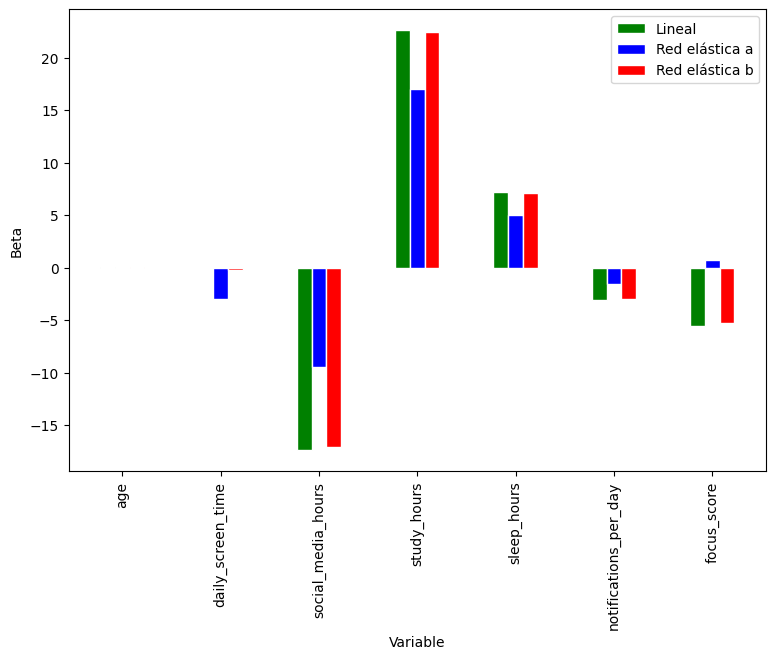

In [42]:
fig = plt.figure(figsize=(9, 6))

#Ancho de barra
barWidth = 0.15

#Definir posicion barras series
r1 = np.arange(len(lm.coef_))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

#Pintar las barras
plt.bar(r1, lm.coef_, color = "green", width = barWidth, edgecolor = "white", label = "Lineal")
plt.bar(r2, e_net.coef_, color = "blue", width = barWidth, edgecolor = "white", label = "Red elástica a")
plt.bar(r3, e_net_b.coef_, color = "red", width = barWidth, edgecolor = "white", label = "Red elástica b")

plt.xticks([r + barWidth for r in range(len(lm.coef_))], 
[predictoras.columns[i] for i in range(len(predictoras.columns))], rotation = 90);
plt.legend();
plt.xlabel("Variable");
plt.ylabel("Beta");
plt.show(fig)

In [43]:
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.model_selection import KFold, cross_val_score

modelo_cv = ElasticNetCV(alphas=alphas,l1_ratio=np.linspace(0.1, 0.99, 10),  
    cv=10,  max_iter=1000, random_state=2026)

modelo_cv.fit(X_train, y_train)

print("El valor de alfa que minimiza el error es %s" %modelo_cv.alpha_)
print("El valor de r que minimiza el error es %s" %modelo_cv.l1_ratio_)

El valor de alfa que minimiza el error es 0.020442874106816167
El valor de r que minimiza el error es 0.99


In [46]:
#realizaremos una predicción
e_net_c = ElasticNet(alpha=modelo_cv.alpha_,l1_ratio=modelo_cv.l1_ratio_, random_state=2026)
e_net_c.fit(X_train, y_train)

#calculamos las medianas
medianas = np.median(X_train, axis=0)
e_net_c.predict(medianas.reshape(1,-1))

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names


array([38.25789582])